In [2]:
!pip install pandas_ta_classic


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import time
import pandas_ta_classic as ta
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier

In [4]:
TICKER = "ECH"
START = "2009-12-12"
END = "2020-01-01" # paper: pre-pandemic window, 01/01/2009-01/01/2020
N_FOLDS = 10
RANDOM_STATE = 0
csv_filename = "ECH-adj-data.csv"

In [13]:
df = pd.read_csv(
    csv_filename,
    header=[0, 1],      # Read the two header rows
    index_col=0,
    parse_dates=True
)

# Flatten the MultiIndex columns
df.columns = df.columns.get_level_values(0).str.lower()

# Make sure numeric columns are numeric
numeric_cols = ["open", "high", "low", "close", "volume"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

print(df.head())
print(df.dtypes)

Price           close       high        low       open  volume
Date                                                          
2009-12-14  35.917553  36.069020  35.496079  35.627787  212300
2009-12-15  35.792431  35.943901  35.726576  35.726576  122100
2009-12-16  35.831932  36.220479  35.759491  36.220479  201500
2009-12-17  35.700222  35.772663  35.298504  35.324846   72300
2009-12-18  35.818764  35.897790  35.232651  35.897790  104900
Price
close     float64
high      float64
low       float64
open      float64
volume      int64
dtype: object


In [14]:
df.shape

(2529, 5)

In [15]:
df.ta.strategy(ta.AllStrategy)

In [16]:
df.shape

(2529, 412)

In [18]:
delta_open = df['open'].diff()
df['gamma'] = np.where(delta_open > 0, 1, -1)

In [20]:
df.shape

(2529, 413)

In [21]:
df.head()

Price,close,high,low,open,volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,VWMACD_12_26_9,VWMACDh_12_26_9,VWMACDs_12_26_9,WAD,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30,gamma
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-14,35.917553,36.069020,35.496079,35.627787,212300,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000,35.850051,NaN,NaN,NaN,NaN,-1
2009-12-15,35.792431,35.943901,35.726576,35.726576,122100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.151470,35.813835,NaN,NaN,NaN,NaN,1
2009-12-16,35.831932,36.220479,35.759491,36.220479,201500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.079028,35.910958,NaN,NaN,NaN,NaN,1
2009-12-17,35.700222,35.772663,35.298504,35.324846,72300,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.210738,35.617903,NaN,NaN,NaN,NaN,-1
2009-12-18,35.818764,35.897790,35.232651,35.897790,104900,35.765204,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.375374,35.691992,NaN,NaN,NaN,NaN,1


In [22]:
df.isna().sum()

Price
close         0
high          0
low           0
open          0
volume        0
             ..
WILLR_14     13
WMA_10        9
ZL_EMA_10    13
ZS_30        29
gamma         0
Length: 413, dtype: int64

In [24]:
nan_counts = df.isna().sum()
print(nan_counts[nan_counts > 0].sort_values(ascending=False))

Price
ACOS               2529
ASIN               2529
PSARs_0.02_0.2     1346
SUPERTs_7_3.0      1338
QQEs_14_5_4.236    1317
                   ... 
MAVP_2_30             1
SAREXT                1
SLOPE_1               1
TRUERANGE_1           1
THERMO_20_2_0.5       1
Length: 253, dtype: int64


In [25]:
print(df.shape)
print(df.isna().sum().max())
print(df.columns[df.isna().all()])
print(len(df.columns[df.isna().all()]))

(2529, 413)
2529
Index(['ACOS', 'ASIN'], dtype='object', name='Price')
2


In [26]:
df = df.dropna(axis=1, how='all')

In [27]:
print(df.isna().sum().sort_values(ascending=False).head(10))

Price
PSARs_0.02_0.2     1346
SUPERTs_7_3.0      1338
QQEs_14_5_4.236    1317
QQEl_14_5_4.236    1282
SUPERTl_7_3.0      1197
PSARl_0.02_0.2     1184
HILOl_13_21        1075
HILOs_13_21        1055
VFI_130             261
TRIXs_30_9           96
dtype: int64


In [28]:
print((df.isna().sum(axis=1) == 0).sum())

print(df.isna().sum().sort_values(ascending=False).head(20))

print(df.shape)

0
Price
PSARs_0.02_0.2       1346
SUPERTs_7_3.0        1338
QQEs_14_5_4.236      1317
QQEl_14_5_4.236      1282
SUPERTl_7_3.0        1197
PSARl_0.02_0.2       1184
HILOl_13_21          1075
HILOs_13_21          1055
VFI_130               261
TRIXs_30_9             96
TRIX_30_9              88
ISB_26                 77
QQE_14_5_4.236         70
QQEb_l_14_5_4.236      69
QQEb_s_14_5_4.236      69
KVOs_34_55_13          66
TRIXs_18_9             60
TRIXh_18_9             60
KVO_34_55_13           54
T3_10_0.7              54
dtype: int64
(2529, 411)


In [29]:
df = df.dropna(axis=1, how='all')

In [30]:
df.shape

(2529, 411)

In [33]:
threshold = int(len(df) * 0.90)  # Keep columns with at least 90% non-NaN values
df = df.dropna(axis=1, thresh=threshold)
df

Price,close,high,low,open,volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,VWMACD_12_26_9,VWMACDh_12_26_9,VWMACDs_12_26_9,WAD,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30,gamma
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-14,35.917553,36.069020,35.496079,35.627787,212300,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000,35.850051,NaN,NaN,NaN,NaN,-1
2009-12-15,35.792431,35.943901,35.726576,35.726576,122100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.151470,35.813835,NaN,NaN,NaN,NaN,1
2009-12-16,35.831932,36.220479,35.759491,36.220479,201500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.079028,35.910958,NaN,NaN,NaN,NaN,1
2009-12-17,35.700222,35.772663,35.298504,35.324846,72300,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.210738,35.617903,NaN,NaN,NaN,NaN,-1
2009-12-18,35.818764,35.897790,35.232651,35.897790,104900,35.765204,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.375374,35.691992,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-24,26.039921,26.210978,25.907737,26.086571,134300,26.130113,26.684685,25.575542,0.554571,24.128291,...,0.999199,0.711398,0.287801,-15.655932,26.049639,-33.626162,26.134064,26.140258,0.920012,-1
2019-12-26,26.102119,26.156547,25.946610,26.039918,295400,26.111451,26.643047,25.579855,0.531596,24.289879,...,1.065922,0.674276,0.391647,-15.500423,26.076849,-36.687273,26.130945,26.131910,0.916694,-1
2019-12-27,26.016590,26.164325,25.767777,26.071018,209700,26.086570,26.609163,25.563978,0.522593,24.465041,...,1.096452,0.590350,0.506102,-15.648158,25.991321,-44.919163,26.105457,26.060049,0.778482,1


In [34]:
df = df.dropna()

print(df.shape)

(2407, 402)


In [35]:
df.head()

Price,close,high,low,open,volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,VWMACD_12_26_9,VWMACDh_12_26_9,VWMACDs_12_26_9,WAD,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30,gamma
Date,,,,,,,,,,,,,,,,,,,,,
2010-05-04,36.627781,37.460380,36.627781,36.918529,153200,36.939226,37.493879,36.384574,0.554653,35.764651,...,-0.139379,-0.284326,0.144946,2.267302,36.835931,-51.026830,36.878752,37.086598,-0.109091,-1
2010-05-05,36.211468,36.429531,35.418515,35.980191,241900,36.892971,37.491265,36.294678,0.598293,35.601709,...,-0.184335,-0.169658,-0.014677,1.850989,36.067745,-63.855532,36.766538,36.800130,-0.792554,-1
2010-05-06,35.240105,36.370061,18.019832,36.019838,270200,35.491209,37.272964,33.709453,1.781756,33.450977,...,-0.327487,-0.233169,-0.094318,0.721033,31.217525,-12.107946,36.485400,36.141639,-2.239805,1
2010-05-07,35.167416,35.927326,34.685037,35.715873,235600,35.096935,36.842726,33.351143,1.745791,33.218167,...,-0.421058,-0.249624,-0.171434,-0.038877,35.236799,-12.478950,36.221083,35.551210,-2.225201,-1
2010-05-10,36.244503,36.997809,36.052875,36.746707,158300,34.898695,36.650126,33.147263,1.751432,33.097308,...,-0.511814,-0.283120,-0.228693,1.038210,36.384923,-6.981509,36.185519,35.607577,-0.715002,1


In [37]:
row_nan_counts = df.isna().sum(axis=1)
print(row_nan_counts)

Date
2010-05-04    0
2010-05-05    0
2010-05-06    0
2010-05-07    0
2010-05-10    0
             ..
2019-11-15    0
2019-11-18    0
2019-11-19    0
2019-11-20    0
2019-11-21    0
Length: 2407, dtype: int64


In [38]:
print(df.isna().sum().sort_values(ascending=False).head(10))

Price
gamma            0
close            0
high             0
low              0
open             0
volume           0
ABER_ZG_5_15     0
ABER_SG_5_15     0
ABER_XG_5_15     0
ABER_ATR_5_15    0
dtype: int64


In [39]:
print(df.isna().sum().max())

0


In [40]:
df = df.dropna()
df

Price,close,high,low,open,volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,VWMACD_12_26_9,VWMACDh_12_26_9,VWMACDs_12_26_9,WAD,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30,gamma
Date,,,,,,,,,,,,,,,,,,,,,
2010-05-04,36.627781,37.460380,36.627781,36.918529,153200,36.939226,37.493879,36.384574,0.554653,35.764651,...,-0.139379,-0.284326,0.144946,2.267302,36.835931,-51.026830,36.878752,37.086598,-0.109091,-1
2010-05-05,36.211468,36.429531,35.418515,35.980191,241900,36.892971,37.491265,36.294678,0.598293,35.601709,...,-0.184335,-0.169658,-0.014677,1.850989,36.067745,-63.855532,36.766538,36.800130,-0.792554,-1
2010-05-06,35.240105,36.370061,18.019832,36.019838,270200,35.491209,37.272964,33.709453,1.781756,33.450977,...,-0.327487,-0.233169,-0.094318,0.721033,31.217525,-12.107946,36.485400,36.141639,-2.239805,1
2010-05-07,35.167416,35.927326,34.685037,35.715873,235600,35.096935,36.842726,33.351143,1.745791,33.218167,...,-0.421058,-0.249624,-0.171434,-0.038877,35.236799,-12.478950,36.221083,35.551210,-2.225201,-1
2010-05-10,36.244503,36.997809,36.052875,36.746707,158300,34.898695,36.650126,33.147263,1.751432,33.097308,...,-0.511814,-0.283120,-0.228693,1.038210,36.384923,-6.981509,36.185519,35.607577,-0.715002,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-11-15,25.812452,26.169342,25.098671,25.370219,1816600,24.366789,25.257199,23.476379,0.890410,25.032656,...,-0.972498,-0.030607,-0.941890,-15.080540,25.723229,-46.315804,24.935886,24.175809,-0.943786,1
2019-11-18,25.812452,26.021932,25.533147,25.936588,936300,24.457305,25.320940,23.593670,0.863635,24.970903,...,-0.871940,0.091471,-0.963411,-15.080540,25.794996,-38.342019,25.013188,24.780899,-0.883784,1
2019-11-19,25.455564,25.509874,25.098672,25.509874,603300,24.756782,25.610427,23.903137,0.853645,24.816774,...,-0.840739,0.126062,-0.966800,-15.437427,25.379919,-45.149867,25.049301,25.195566,-0.994106,-1


In [42]:
non_feature_cols = ["gamma"]

In [43]:
feature_cols = [c for c in df.columns if c not in non_feature_cols]
X_raw = df[feature_cols].astype(float)
y = df["gamma"].to_numpy()

In [44]:
X_raw = df[feature_cols].astype(float)
X_norm = (X_raw - X_raw.min()) / (X_raw.max() - X_raw.min())

In [45]:
X_norm.head()

Price,close,high,low,open,volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,...,VWMA_10,VWMACD_12_26_9,VWMACDh_12_26_9,VWMACDs_12_26_9,WAD,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30
Date,,,,,,,,,,,,,,,,,,,,,
2010-05-04,0.475395,0.498111,0.530097,0.488628,0.064849,0.489330,0.490308,0.488335,0.154851,0.488825,...,0.486947,0.470355,0.327703,0.516880,0.483762,0.484852,0.489732,0.489214,0.491987,0.520546
2010-05-05,0.462471,0.466007,0.495648,0.459671,0.110319,0.487868,0.490226,0.485470,0.184908,0.483364,...,0.483942,0.463568,0.359748,0.490988,0.473615,0.460960,0.361445,0.485647,0.483074,0.417787
2010-05-06,0.432314,0.464155,0.000000,0.460895,0.124827,0.443561,0.483384,0.403058,1.000000,0.411294,...,0.472749,0.441956,0.341999,0.478070,0.446071,0.310110,0.878921,0.476709,0.462586,0.200193
2010-05-07,0.430057,0.450367,0.474753,0.451515,0.107090,0.431099,0.469900,0.391636,0.975230,0.403493,...,0.466154,0.427828,0.337401,0.465561,0.427548,0.435116,0.875211,0.468306,0.444215,0.202389
2010-05-10,0.463496,0.483705,0.513720,0.483326,0.067463,0.424833,0.463863,0.385137,0.979115,0.399443,...,0.465007,0.414126,0.328040,0.456274,0.453802,0.470825,0.930185,0.467175,0.445969,0.429447


In [46]:
print("Infinite values:", np.isinf(X_norm).sum().sum())
print("NaN values:", X_norm.isna().sum().sum())
print("Shape:", X_norm.shape)

Infinite values: 0
NaN values: 38512
Shape: (2407, 401)


In [47]:
nan_counts = X_norm.isna().sum().sort_values(ascending=False)
print(nan_counts.head(30))

Price
CDL_IDENTICAL3CROWS     2407
SUB                     2407
CDL_3STARSINSOUTH       2407
CDL_KICKING             2407
CDL_KICKINGBYLENGTH     2407
SQZ_NO                  2407
TANH                    2407
close_X_close           2407
close_XA_close          2407
CDL_MATHOLD             2407
CDL_RISEFALL3METHODS    2407
SQZPRO_NO               2407
DIV                     2407
CDL_BREAKAWAY           2407
CDL_CONCEALBABYSWALL    2407
CDL_COUNTERATTACK       2407
ROUND                      0
NVI_1                      0
PSARaf_0.02_0.2            0
OHLC4                      0
PDIST                      0
PPOs_12_26_9               0
PCTRET_1                   0
PGO_14                     0
PPOh_12_26_9               0
PPO_12_26_9                0
PSARr_0.02_0.2             0
PO_14                      0
PMAX_E_10_3.0              0
PLUS_DM_14                 0
dtype: int64


In [48]:
X_norm = X_norm.dropna(axis=1, how='all')
X_norm.shape

(2407, 385)

In [49]:
X_norm.isna().sum().sum()

np.int64(0)

In [50]:
constant_cols = X_norm.columns[X_norm.nunique() <= 1]

print(len(constant_cols))
print(constant_cols)

0
Index([], dtype='object', name='Price')


In [52]:
print(y)

[-1 -1  1 ... -1 -1 -1]


In [64]:
corr_matrix = X_norm.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns 
    if any(upper[column] > 0.98)
]

print(len(high_corr))

169


In [65]:
X_reduced = X_norm.drop(columns=high_corr)

print(X_reduced.shape)

(2407, 216)


In [66]:
for keyword in ['RSI', 'MACD', 'ATR', 'BB', 'SMA', 'EMA', 'ADX', 'ROC']:
    print(keyword, sum(keyword in col for col in X_reduced.columns))

RSI 5
MACD 6
ATR 2
BB 2
SMA 1
EMA 0
ADX 2
ROC 1


In [67]:
X_reduced.shape[1]

216

In [68]:
print(X_reduced.isna().sum().sum())

0


In [76]:
print(X_reduced.shape)
print(y.shape)

print(X_reduced.index.equals(y.index))

(2407, 216)
(2407,)
True


In [73]:
y = df['gamma']
y

Date
2010-05-04   -1
2010-05-05   -1
2010-05-06    1
2010-05-07   -1
2010-05-10    1
             ..
2019-11-15    1
2019-11-18    1
2019-11-19   -1
2019-11-20   -1
2019-11-21   -1
Name: gamma, Length: 2407, dtype: int64

In [74]:
y.value_counts()

gamma
-1    1210
 1    1197
Name: count, dtype: int64

In [92]:
feature_cols = X_reduced.columns.tolist()
print(f"[{TICKER}] usable features after cleaning: {len(feature_cols)}")

[ECH] usable features after cleaning: 216


In [93]:
Xf = X_reduced

corr = Xf.apply(lambda col: abs(np.corrcoef(col, y)[0, 1]) if col.std() > 0 else 0.0)
corr = corr.sort_values(ascending=False)

In [94]:
# Fraction of (correlation-ranked) features kept at each level.
# 100% = baseline / no selection, decreasing toward the most selective subset.
LEVELS = [100, 75, 50, 25, 10, 5, 1]

In [95]:
selected = {}
for level in LEVELS:
    k = max(1, int(len(feature_cols) * level / 100))
    selected[level] = corr.index[:k].tolist()

In [96]:
print("\nNumber of features selected per top-% level (correlation-ranked):")
for level in LEVELS:
    print(f"  top {level}%: {len(selected[level])} features")


Number of features selected per top-% level (correlation-ranked):
  top 100%: 216 features
  top 75%: 162 features
  top 50%: 108 features
  top 25%: 54 features
  top 10%: 21 features
  top 5%: 10 features
  top 1%: 2 features


In [97]:
def cv_median_accuracy(X_sub: pd.DataFrame, y: np.ndarray, n_splits=N_FOLDS) -> float:
    cv = StratifiedKFold(n_splits=n_splits, shuffle=False)
    accs = []
    for train_idx, test_idx in cv.split(X_sub, y):
        X_train, X_test = X_sub.iloc[train_idx], X_sub.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        hidden_layer_sizes = int((X_train.shape[1] + len(np.unique(y_train))) / 2)
        clf = MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            activation="logistic",
            solver="lbfgs",
            batch_size="auto",
            learning_rate="adaptive",
            learning_rate_init=0.03,
            max_iter=5000,
            momentum=0.2,
            random_state=np.random.get_state()[1][0],
            early_stopping=False,
        )
        clf.fit(X_train, y_train)
        accs.append(clf.score(X_test, y_test))
    return float(np.median(accs) * 100)

In [98]:
results = {}
for level in LEVELS:
    feats = selected[level]
    results[level] = cv_median_accuracy(X_reduced[feats], y) if len(feats) > 0 else np.nan
    print(f"  top {level}% -> median accuracy = {results[level]:.2f}%  ({len(feats)} features)")

/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__ge

  top 100% -> median accuracy = 84.17%  (216 features)


/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__ge

  top 75% -> median accuracy = 83.61%  (162 features)


/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__ge

...

/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__ge

  top 5% -> median accuracy = 75.52%  (10 features)


/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__ge

  top 1% -> median accuracy = 73.60%  (2 features)


/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/tmp/ipykernel_38/2430815419.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]


In [99]:
table4 = pd.DataFrame([results], index=[TICKER])
table4.columns = [f"top{level}%" for level in table4.columns]
print("\n=== Table 4 (single fund): Median accuracy after cross-validation (%) ===")
print(table4.round(2).to_string())
table4.round(2).to_csv(f"table4_{TICKER}.csv")


=== Table 4 (single fund): Median accuracy after cross-validation (%) ===
     top100%  top75%  top50%  top25%  top10%  top5%  top1%
ECH    84.17   83.61   82.99   82.95   81.91  75.52   73.6


In [100]:
TOP5_LEVEL = 5
table5 = pd.DataFrame({"ETF": [TICKER], "Top 5% by correlation": [", ".join(selected[TOP5_LEVEL])]})
print("\n=== Table 5 (single fund): Features in top-5% correlation subset ===")
print(table5.to_string(index=False))
table5.to_csv(f"table5_{TICKER}.csv", index=False)


=== Table 5 (single fund): Features in top-5% correlation subset ===
ETF                                                                                               Top 5% by correlation
ECH MSW_SINE_5, BBP_5_2.0, STOCHFk_5_3, CPR_POSITION, TTM_TRND_6, CCI_14_0.015, PO_14, SMIo_5_20_5, BULLP_13, AOBV_LR_2


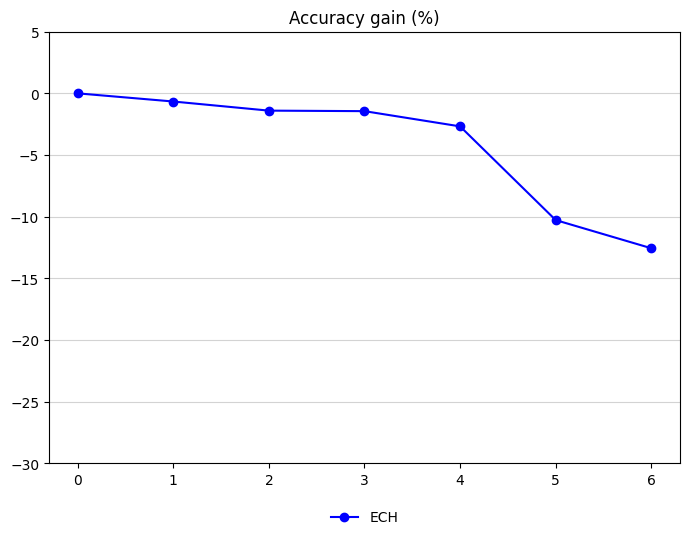

In [101]:
baseline = results[100]
gain_pct = [(results[level] - baseline) / baseline * 100 for level in LEVELS]
positions = list(range(len(LEVELS)))
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(positions, gain_pct, marker="o", color="blue", label=TICKER)
ax.set_ylim(-30, 5)
ax.set_yticks(range(5, -31, -5))
ax.set_xticks(positions)
ax.grid(axis="y", color="lightgray", linewidth=0.8)
ax.set_title("Accuracy gain (%)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
plt.tight_layout()
plt.show()